## To create NN which can classify whether the given data belongs to which number.A number can range from 0 to 9.


In [ ]:
25 * 25 == 625

50 MP ---> 50 X 10^6 == 50 X 1000000 ==> 50000000 pixel

SyntaxError: invalid syntax (ipython-input-594165412.py, line 3)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
import keras
from keras.datasets.mnist import load_data
import seaborn as sns

Loading the MNIST inbuilt dataset

In [2]:
# data=keras.datasets.mnist      mnist data is image dataset
(X_train,y_train),(X_test,y_test)=load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
X_train.shape   ## 28,28 thats the size of image

(60000, 28, 28)

In [4]:
type(X_train[2])

numpy.ndarray

In [5]:
X_train[847]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   4, 184, 242,  63,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   5, 254, 254,  74,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  66,  73,   0,
          0,   0,   0,   0,   0,   0,   0,   0, 111, 254, 241,  40,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 154, 252, 253,  64,
          0,   0,   0,   0,   0,   0,  17, 196, 253, 228,  21,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 156, 254, 254,  94,
          0,   0,   0,   0,   0,   0,  82, 254, 254, 196,   5,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  20, 202, 254, 215,  12,
          0,   0,   0,   0,   0,   7, 230, 254, 250,  53,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  54, 245, 254, 254,  16,   0,
          0,   0,   0,   0,   0, 175, 254, 254, 120,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  21, 201, 254, 254, 174,   2,   0,
          0,   0,   0,   0,  27, 209, 254, 236,  48,   6,  10,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  21, 203, 254, 254, 206,  22,   0,   0,
          0,   0,   0,   0, 170, 254, 254, 118,   4, 198, 125,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 244, 254, 254, 254, 121,  32,   0,   0,
          0,   0,   0, 128, 253, 254, 127, 136, 219, 228,  23,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 255, 254, 254, 254, 254, 237, 150,  75,
         44,  15,  20, 208, 254, 254, 254, 254, 253, 188,   6,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 177, 177, 106, 156, 254, 254, 254, 254,
        254, 254, 254, 254, 254, 254, 254, 254, 154,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   5, 101, 183, 219, 254,
        254, 254, 254, 254, 230, 207,  51,  19,   5,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11,  60,
        222, 254, 254, 254, 111,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        141, 254, 254, 175,   7,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  91,
        247, 254, 240,   8,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  96,
        254, 254, 127,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35, 238,
        254, 223,  17,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 211, 254,
        212,  28,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [6]:
pd.set_option("display.max_columns",None)
pd.DataFrame(X_train[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,3,18,18,18,126,136,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,94,154,170,253,253,253,253,253,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,253,253,253,253,253,253,253,251,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,253,253,253,253,198,182,247,241,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,107,253,253,205,11,0,43,154,0,0,0,0,0,0,0,0,0,0


In [7]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [8]:
y_train[1]

np.uint8(0)

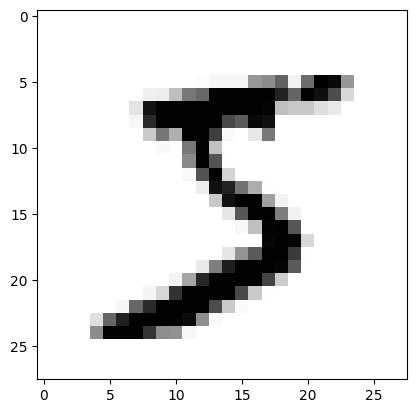

In [ ]:
plt.imshow(X_train[0],cmap='Grays')      # imshow that means showing the image & cmap is the color map

<Axes: >

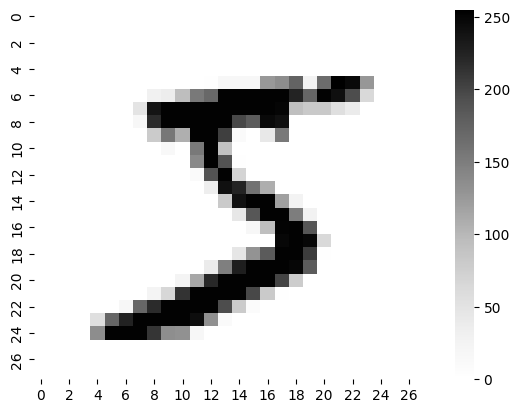

In [ ]:
import seaborn as sns
sns.heatmap(X_train[0],cmap='Grays')

In [ ]:
y_train[0]

np.uint8(5)

In [ ]:
from google.colab.patches import cv2_imshow   # Import special image display function for Colab
cv2_imshow(X_train[0])

In [ ]:
plt.figure(figsize=(30,30))
from PIL import Image        # Python Imaging Library
Image.fromarray(X_train[0])  # Converts the numpy array X_train[0] → into an actual image object.

<Figure size 3000x3000 with 0 Axes>

In [ ]:
plt.figure(figsize=(20,20))
from google.colab.patches import cv2_imshow
cv2_imshow(X_train[1])

<Figure size 2000x2000 with 0 Axes>

<Axes: >

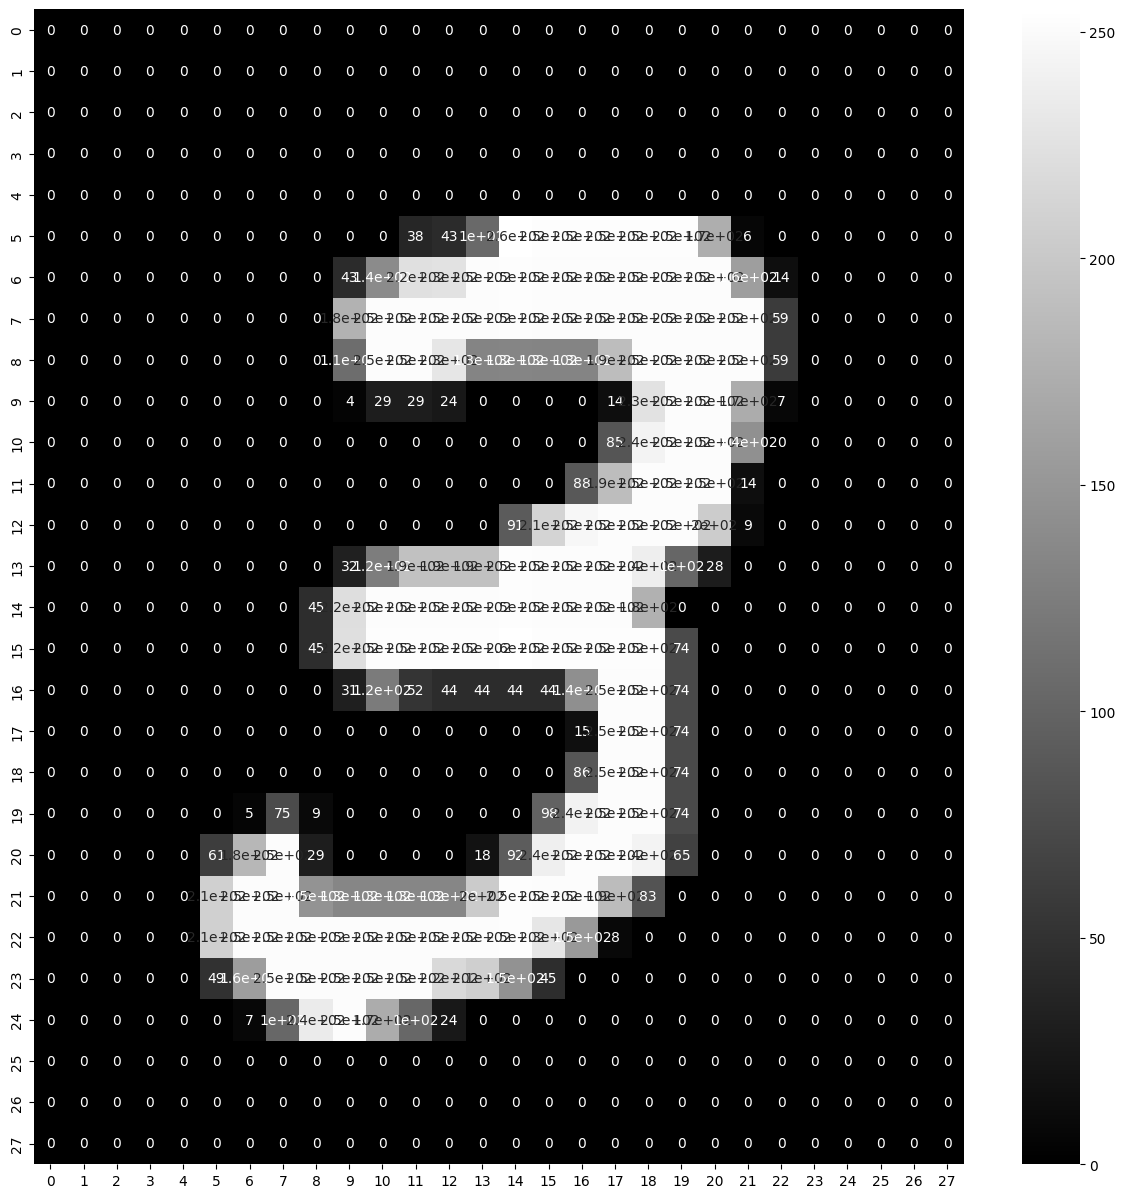

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(X_train[7],cmap='gray',annot=True)

In [ ]:
y_train[7]

np.uint8(3)

Validation data creation

In [ ]:
print(len(X_train))
print(len(X_test))

60000
10000


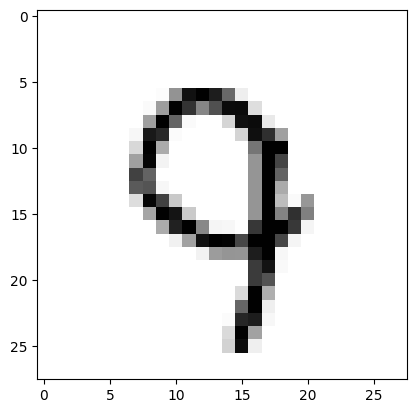

In [ ]:
plt.imshow(X_test[999],cmap="Grays")

In [ ]:
X_test[999]/255

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [ ]:
# split training data for validation & training

In [ ]:
x_valid,x_train=X_train[:5000]/255,X_train[5000:]/255  # first 5000 records validation (scaling them)
y_valid,y_train=y_train[:5000],y_train[5000:]

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_valid.shape)
print(y_valid.shape)
print(X_test.shape)
print(y_test.shape)

(55000, 28, 28)
(55000,)
(5000, 28, 28)
(5000,)
(10000, 28, 28)
(10000,)


Visualize the data

Building Model Architecture

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_valid.shape)
print(y_valid.shape)
print(len(np.unique(y_train)))

(55000, 28, 28)
(55000,)
(5000, 28, 28)
(5000,)
10


In [ ]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
LAYERS = [
          tf.keras.layers.Flatten(input_shape=[28, 28], name="InputLayer"),
          tf.keras.layers.Dense(500, activation="relu", name="HiddenLayer1"),
          tf.keras.layers.Dense(100, activation="relu", name="HiddenLayer2"),
          tf.keras.layers.Dense(10, activation="softmax", name="outputLayer"),

]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model = tf.keras.models.Sequential(LAYERS)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HiddenLayer1 (Dense)            │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HiddenLayer2 (Dense)            │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,610 (1.69 MB)

 Trainable params: 443,610 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
weights,bias = model.layers[1].get_weights()

In [ ]:
weights.shape

(784, 500)

In [ ]:
bias.shape

(500,)

In [ ]:
bias

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
myarr = weights.flatten()
print(myarr.ndim)
print(len(myarr))

1
392000


<Axes: ylabel='Density'>

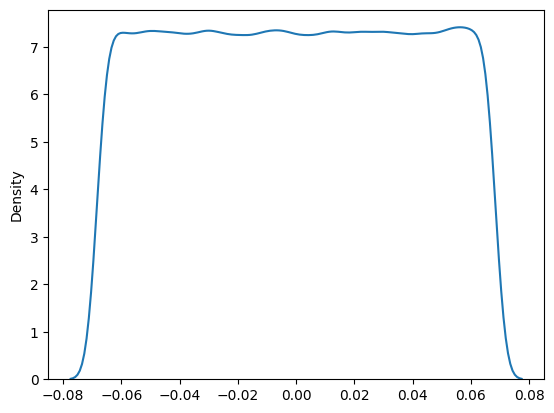

In [ ]:
sns.kdeplot(myarr)

<Axes: ylabel='Density'>

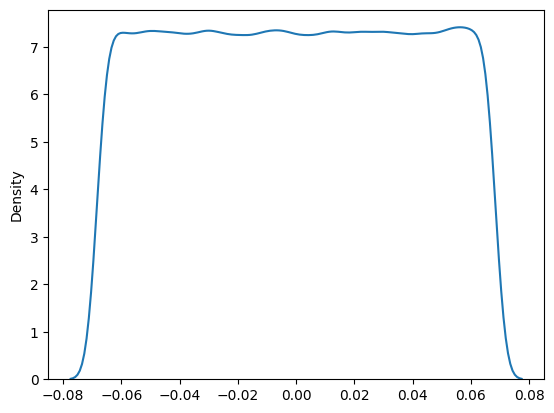

In [ ]:
sns.kdeplot(myarr)

<Axes: ylabel='Density'>

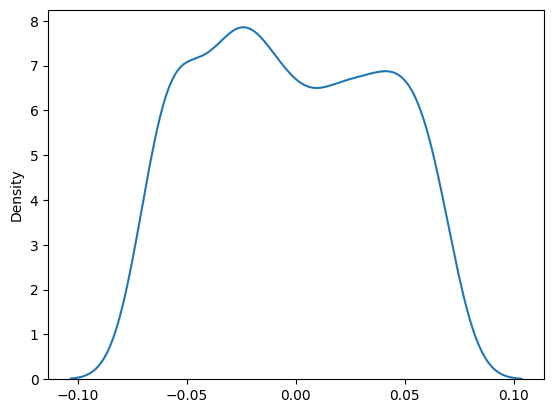

In [ ]:
import seaborn as sns
sns.kdeplot(weights[0,:])

In [ ]:
bias

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HiddenLayer1 (Dense)            │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HiddenLayer2 (Dense)            │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,610 (1.69 MB)

 Trainable params: 443,610 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
LOSS_FUNCTION = "sparse_categorical_crossentropy"
OPTIMIZER = "adam"
METRICS = ["accuracy"]

model.compile(loss=LOSS_FUNCTION,
              optimizer=OPTIMIZER,
              metrics=METRICS)


### Important -

* **Epochs**: Integer.
    
    Number of epochs to train the model. An epoch is an iteration over the entire x and y data provided.

* **batch_size**: Integer or None.
    
    Number of samples per gradient update. If unspecified, batch_size will default to 32.
    
    *NOTE:* Do not specify the batch_size if your data is in the form of datasets, generators, or keras.utils.Sequence instances (since they generate batches).

* **validation_batch_size**: Integer or None.

    Number of samples per validation batch.
    
    If unspecified, will default to batch_size.
    
    *NOTE:* Do not specify the validation_batch_size if your data is in the form of datasets, generators, or keras.utils.Sequence instances (since they generate batches).

[Reference](https://www.tensorflow.org/api_docs/python/tf/keras/Model?hl=zh-tw#fit)

In [ ]:
 ## Training the model
EPOCHS = 10
VALIDATION_SET = (x_valid, y_valid)

history = model.fit(x_train, y_train,
                    epochs=EPOCHS,
                    validation_data=VALIDATION_SET)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8980 - loss: 0.3387 - val_accuracy: 0.9652 - val_loss: 0.1094
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9740 - loss: 0.0819 - val_accuracy: 0.9778 - val_loss: 0.0811
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9822 - loss: 0.0577 - val_accuracy: 0.9786 - val_loss: 0.0811
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9896 - loss: 0.0339 - val_accuracy: 0.9818 - val_loss: 0.0623
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9826 - val_loss: 0.0716
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9927 - loss: 0.0227 - val_accuracy: 0.9728 - val_loss: 0.1058
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9931 - loss: 0.0197 - val_accuracy: 0.9794 - val_loss: 0.0919
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9942 - loss: 0.0188 - 

In [ ]:
model.evaluate(X_test, y_test) ## evaluating model on testing data

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9799 - loss: 25.6497


[20.300649642944336, 0.9814000129699707]

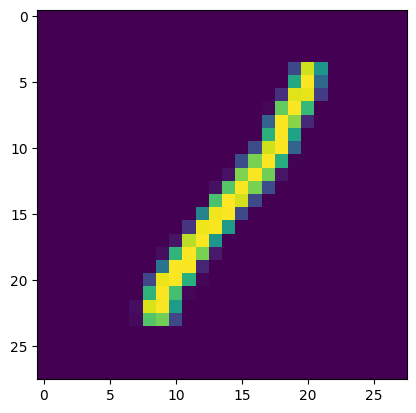

In [ ]:
plt.imshow(X_test[354])

In [ ]:
y_test[354]

np.uint8(1)

In [ ]:
np.argmax(model.predict((X_test[540]/255).reshape(1,28,28)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step


np.int64(5)

In [ ]:
model.predict((X_test[354]/255).reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[3.8229342e-16, 1.0000000e+00, 1.7460274e-10, 1.8982044e-13,
        4.7387525e-09, 4.1253088e-15, 1.2863579e-13, 2.0009218e-10,
        1.5342718e-09, 8.7940900e-15]], dtype=float32)

In [ ]:
np.argmax(model.predict(X_test[46].reshape(1,28,28)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


np.int64(1)

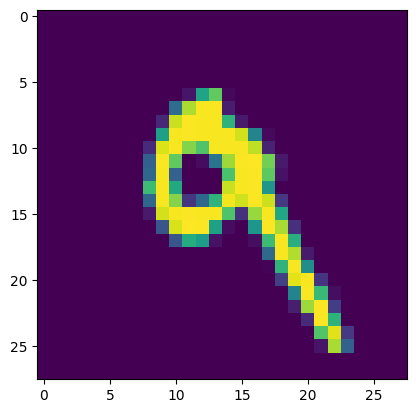

In [ ]:
plt.imshow(X_test[7])

In [ ]:
y_test[7]

np.uint8(9)

In [ ]:
np.argmax(model.predict(X_test[7].reshape(1,28,28)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


np.int64(9)

In [ ]:
model.save("nisarg.keras")  ## Saving the model

In [ ]:
loaded_model = tf.keras.models.load_model("/content/nisarg.keras") ## Loading the saved model

In [ ]:
history.history

{'accuracy': [0.9408727288246155,
  0.9743090867996216,
  0.9819090962409973,
  0.9879454374313354,
  0.9894545674324036,
  0.9910908937454224,
  0.9924727082252502,
  0.9936909079551697,
  0.9940727353096008,
  0.995199978351593],
 'loss': [0.19709190726280212,
  0.08109784126281738,
  0.05713889002799988,
  0.039957303553819656,
  0.0330851748585701,
  0.027239978313446045,
  0.021864280104637146,
  0.020698625594377518,
  0.0180486012250185,
  0.015175518579781055],
 'val_accuracy': [0.9652000069618225,
  0.9778000116348267,
  0.978600025177002,
  0.9818000197410583,
  0.9825999736785889,
  0.9728000164031982,
  0.9793999791145325,
  0.9761999845504761,
  0.9800000190734863,
  0.9800000190734863],
 'val_loss': [0.1093839630484581,
  0.08112964779138565,
  0.0810752585530281,
  0.062348026782274246,
  0.07161043584346771,
  0.1057625338435173,
  0.09185344725847244,
  0.11036253720521927,
  0.09449725598096848,
  0.0949946790933609]}

In [ ]:
history.history['val_accuracy']

[0.9652000069618225,
 0.9778000116348267,
 0.978600025177002,
 0.9818000197410583,
 0.9825999736785889,
 0.9728000164031982,
 0.9793999791145325,
 0.9761999845504761,
 0.9800000190734863,
 0.9800000190734863]

In [ ]:
history.history['accuracy']

[0.9408727288246155,
 0.9743090867996216,
 0.9819090962409973,
 0.9879454374313354,
 0.9894545674324036,
 0.9910908937454224,
 0.9924727082252502,
 0.9936909079551697,
 0.9940727353096008,
 0.995199978351593]

In [ ]:
model.get_weights()

[array([[-0.0542406 ,  0.05713988, -0.02932158, ...,  0.05437201,
          0.04281648, -0.03000395],
        [-0.00608271, -0.00747802, -0.05236427, ...,  0.03685159,
          0.05627818, -0.0625146 ],
        [-0.04732271,  0.00850118, -0.00444791, ..., -0.05744742,
         -0.03331319, -0.02833876],
        ...,
        [ 0.05890097, -0.06342124, -0.02303452, ..., -0.02389602,
         -0.04528851, -0.04393547],
        [-0.0023023 ,  0.02658991,  0.01238925, ...,  0.02214676,
          0.02467777,  0.03042968],
        [ 0.04646126, -0.05084168,  0.04179701, ...,  0.06457593,
          0.04933571,  0.05436044]], dtype=float32),
 array([-0.00979801, -0.02357602, -0.05766864, -0.00241079, -0.08100607,
        -0.0725989 ,  0.0886043 , -0.05549454,  0.05105049,  0.01152906,
         0.07748389,  0.03432307, -0.00665188,  0.0367228 , -0.03217719,
         0.03946189,  0.02763908, -0.0193158 , -0.09500696, -0.04417207,
        -0.1217766 , -0.18576114,  0.10937618, -0.01788589, -0.020

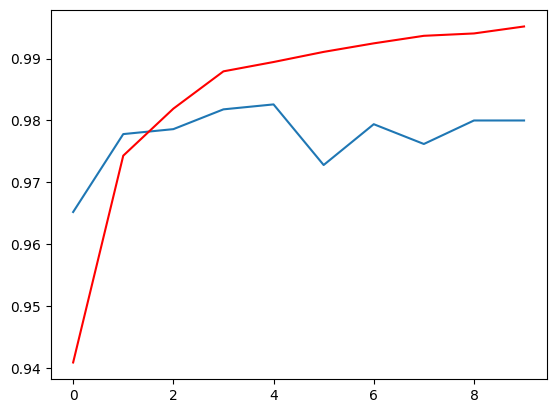

In [ ]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'],color = 'red')

In [ ]:
## Creating metrix for performance during training
import pandas as pd
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.940873,0.197092,0.9652,0.109384
1,0.974309,0.081098,0.9778,0.081130
2,0.981909,0.057139,0.9786,0.081075
3,0.987945,0.039957,0.9818,0.062348
4,0.989455,0.033085,0.9826,0.071610
5,0.991091,0.027240,0.9728,0.105763
6,0.992473,0.021864,0.9794,0.091853
7,0.993691,0.020699,0.9762,0.110363
8,0.994073,0.018049,0.9800,0.094497
9,0.995200,0.015176,0.9800,0.094995


In [ ]:
X_new = X_test[:3]
y_new = y_test[:3]
y_proba = model.predict(X_new)
y_proba


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step


array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
import numpy as np
y_pred = np.argmax(y_proba, axis=-1)
y_pred, y_new

(array([7, 2, 1]), array([7, 2, 1], dtype=uint8))

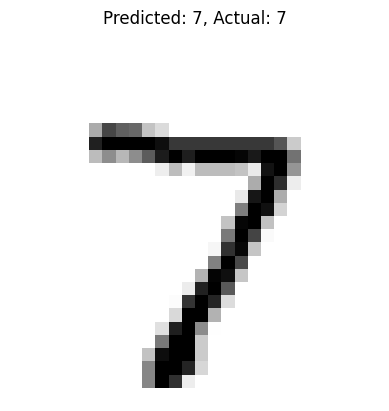

------------------------------------------------------------


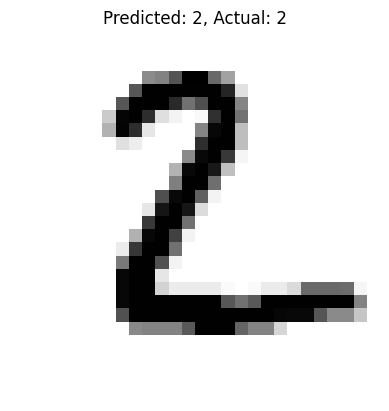

------------------------------------------------------------


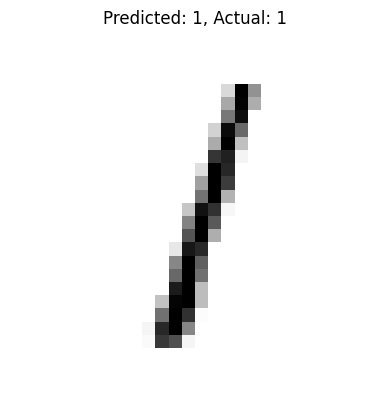

------------------------------------------------------------


In [ ]:
for data, pred, actual in zip(X_new, y_pred, y_new):
  plt.imshow(data, cmap="binary")
  plt.title(f"Predicted: {pred}, Actual: {actual}")
  plt.axis("off")
  plt.show()
  print("---"*20)

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

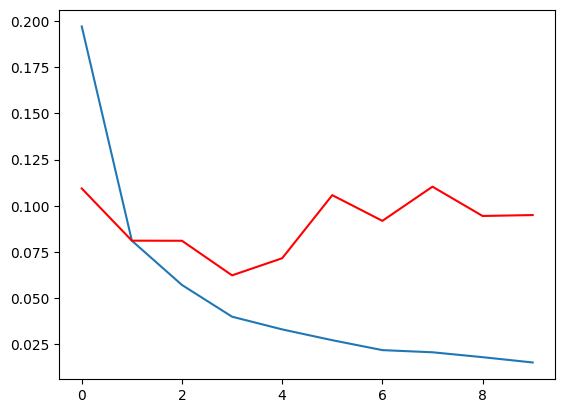

In [ ]:
plt.plot(train_loss)
plt.plot(val_loss,color='red')